Problem Statement:
Build an Image Classifier with CNN — Load the CSV file (a random 5,000-row sample is plenty), separate the label column, reshape the remaining 784 pixel columns to 28×28×1 per row, and normalize pixel values to 0–1 (divide by 255). Build this exact CNN in Keras: Conv2D(32, 3x3, activation="relu") → MaxPooling2D → Conv2D(64, 3x3, activation="relu") → MaxPooling2D → Flatten → Dense(64, activation="relu") → Dense(n_classes, activation="softmax"). Train for 5 epochs and report test accuracy. Display 5 sample test images next to their true and predicted labels.

Deliverables
* Notebook that loads the CSV, reshapes to 28×28×1, normalizes (÷255), and trains the exact CNN given above; report test accuracy
* A plot of training vs. validation accuracy
* A small grid of 5 sample predictions (image, true label, predicted label)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, Convolution2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras import Sequential


from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# Load the data

X_train = pd.read_csv("fashion-mnist_train.csv").sample(n=5000, random_state=42)
X_test = pd.read_csv("fashion-mnist_test.csv").sample(n=1000, random_state=42)

In [3]:
y_train = X_train["label"].values
X_train = X_train.drop(columns=["label"]).values

y_test = X_test["label"].values
X_test = X_test.drop(columns=["label"]).values

In [4]:
print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

Training Images Shape: (5000, 784)
Training Labels Shape: (5000,)
Testing Images Shape: (1000, 784)
Testing Labels Shape: (1000,)


In [5]:
# Normalize

X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

In [6]:
print(X_train.min())
print(X_train.max())

0.0
1.0


In [7]:
# Reshape

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [8]:
print(X_train.shape)
print(X_test.shape)

(5000, 28, 28, 1)
(1000, 28, 28, 1)


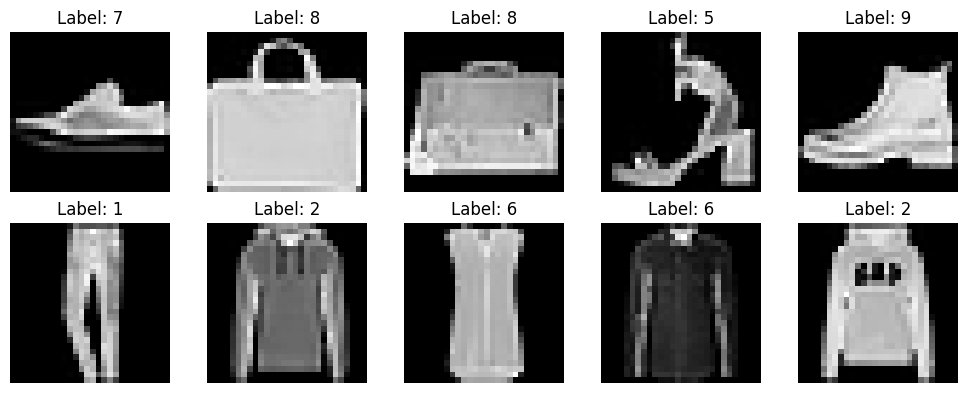

In [9]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# Build the model

model = Sequential ([
    Input(shape=(28, 28, 1)),

    Convolution2D(32, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size= (2, 2)),

    Convolution2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size= (2, 2)),

    Flatten(),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compile the model

model.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

In [12]:
# Train the model

history = model.fit(
    X_train,
    y_train,
    epochs = 10,
    batch_size=32,
    validation_split = 0.2,
    verbose = 1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.5253 - loss: 1.3179 - val_accuracy: 0.7380 - val_loss: 0.7261
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.7000 - loss: 0.8120 - val_accuracy: 0.7550 - val_loss: 0.6468
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7420 - loss: 0.7046 - val_accuracy: 0.7710 - val_loss: 0.5705
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7602 - loss: 0.6379 - val_accuracy: 0.7840 - val_loss: 0.5525
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.7847 - loss: 0.5816 - val_accuracy: 0.7890 - val_loss: 0.5155
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.7910 - loss: 0.5611 - val_accuracy: 0.8030 - val_loss: 0.4946
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8010 - loss: 0.5269 - val_accuracy: 0.8040 - val_loss: 0.5080
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.8117 - loss: 0.5129 - val_accu

In [13]:
# Evaluate the data

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.4729310870170593
Test Accuracy: 0.8220000267028809


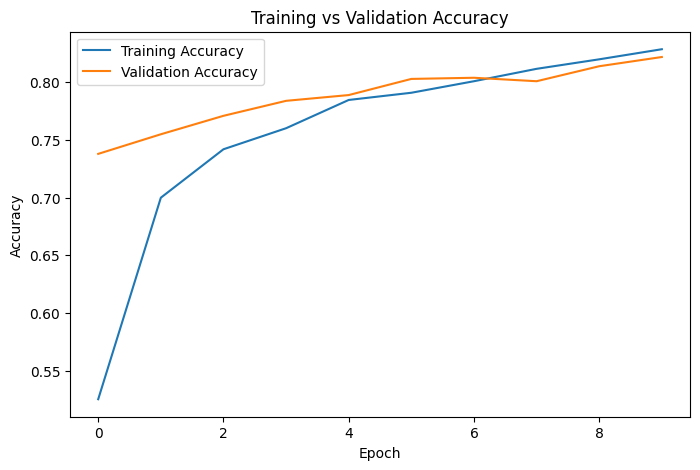

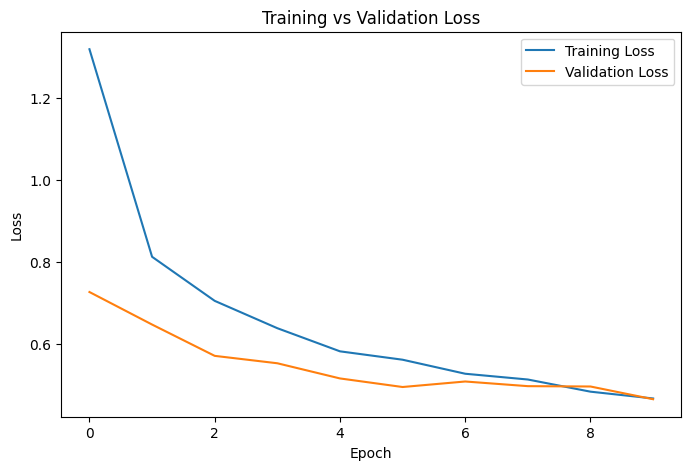

In [14]:
# Plotting

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


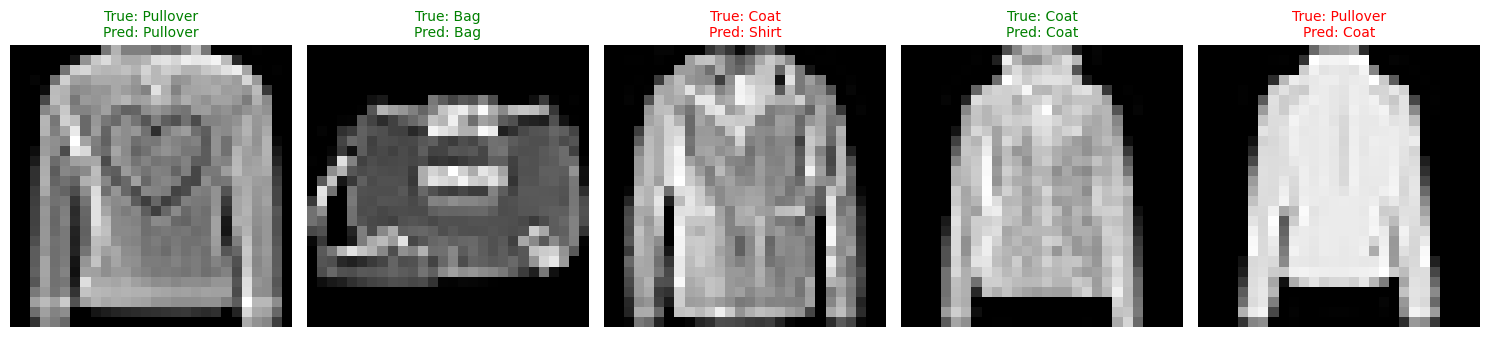

In [15]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

sample_indices = np.random.choice(len(X_test), 5, replace=False)
sample_images = X_test[sample_indices]
sample_labels = y_test[sample_indices]

predictions = model.predict(sample_images)
predicted_classes = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))

for i, ax in enumerate(axes):
    ax.imshow(sample_images[i].squeeze(), cmap="gray")
    true_name = class_names[sample_labels[i]]
    pred_name = class_names[predicted_classes[i]]

    color = "green" if sample_labels[i] == predicted_classes[i] else "red"
    ax.set_title(f"True: {true_name}\nPred: {pred_name}", color=color, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()